#Day 26 Gradient Boosting untuk Regresi

**Gradient Boosting** membangun pohon secara **berurutan**: tiap pohon baru
memperbaiki kesalahan pohon sebelumnya. Hasilnya sering jadi salah satu model
paling akurat untuk data tabular. Kita pakai data harga rumah Boston, lihat
pengaruh **n_estimators** & **learning_rate**, lalu bandingkan dengan Random Forest.

> 🎯 **Tujuan Pembelajaran**
> - Memahami ide *boosting* (belajar dari kesalahan secara bertahap).
> - Melatih **GradientBoostingRegressor**.
> - Menyetel **n_estimators** & **learning_rate** dan melihat efeknya.
> - Membandingkan Gradient Boosting vs Random Forest + feature importance.

## Tentang Dataset

**Boston Housing** — harga rumah & atribut lingkungan (506 baris × 14 kolom).

- **Sumber:** [Kaggle — fedesoriano/the-boston-houseprice-data](https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data)
- **Target:** `MEDV` (harga median rumah, ribuan USD).
- **Fitur penting:** `RM` (kamar), `LSTAT` (% ekonomi rendah), `PTRATIO`, `CRIM`, `NOX`, `TAX`, dll.

## Import Library

- **scikit-learn** → `GradientBoostingRegressor`, `RandomForestRegressor`, metrik.
- **pandas/numpy/seaborn/matplotlib** → olah data & grafik.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## Import Dataset

In [2]:
!pip install kaggle
!kaggle datasets download -d fedesoriano/the-boston-houseprice-data
!unzip the-boston-houseprice-data.zip

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data
License(s): copyright-authors
100% 12.3k/12.3k [00:00<00:00, 6.86MB/s]

Archive:  the-boston-houseprice-data.zip
  inflating: boston.csv              


## Eksplorasi Awal Dataset

In [3]:
df = pd.read_csv('boston.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [6]:
df.isna().sum().sum()

np.int64(0)

Interpretasi:
- 506 baris tanpa missing value.
- Median harga (MEDV) berkisar dari ~5 hingga 50 (ribuan USD), dengan rata-rata sekitar 22.
- Nilai 50 kemungkinan adalah batas atas yang dipotong (capped).
- Model berbasis Pohon ( Boosting ) tidak memerlukan Scaling

## Eksplorasi Data Analisis dan Visualisasi

### a) Heatmap Korelasi

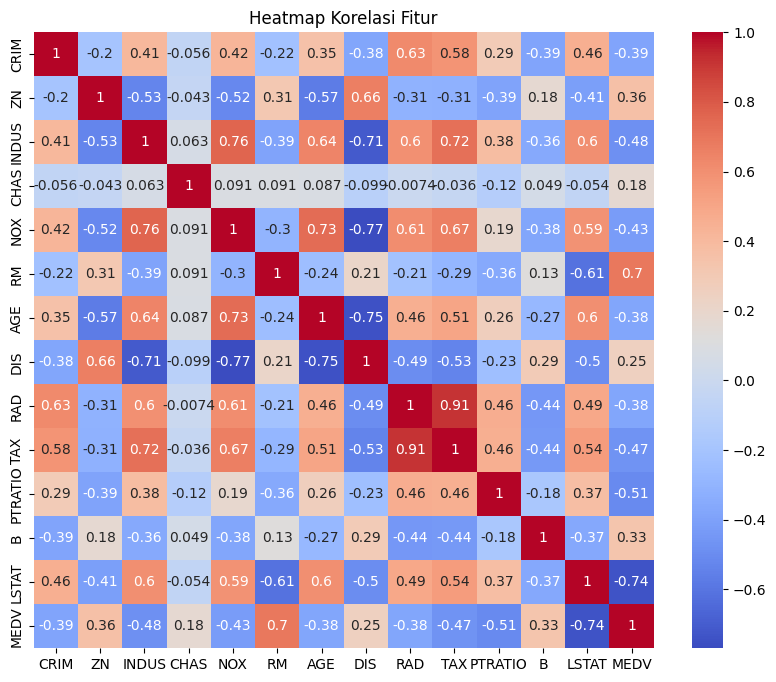

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi Fitur')

plt.show()

Interpretasi:
- `RM` mempunyain korelasi positif kuat dengan MEDV
- `LSTAT`(status ekonomi rendah) mempunyai kolerasi negatif kuat dengan MEDV,
Beberapa fitur saling berkorelasi (mis. `RAD` & `TAX`, `NOX` & `INDUS`).
- Korelasi antar fitur (multikolinearitas) membuat koefisien linear biasa tidak stabil

### b) Korelasi Fitur terhadap Target

In [8]:
corr_y = df.corr()["MEDV"].drop("MEDV").sort_values()

/tmp/ipykernel_6120/900566571.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(corr_y[i], i, round(corr_y[i], 2), ha="right", va="center")


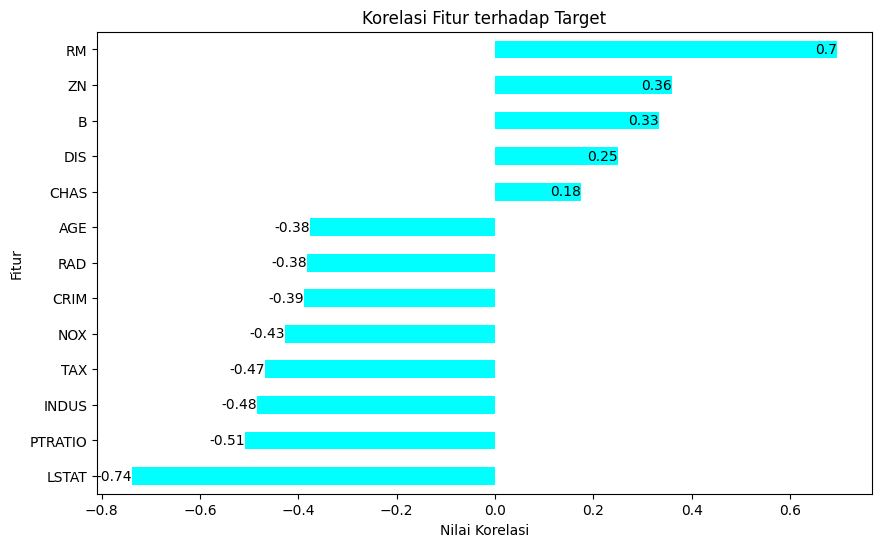

In [9]:
corr_y.plot(kind="barh", color="cyan", figsize=(10, 6))
plt.title("Korelasi Fitur terhadap Target")
plt.xlabel("Nilai Korelasi")
plt.ylabel("Fitur")
for i in range(len(corr_y)):
    plt.text(corr_y[i], i, round(corr_y[i], 2), ha="right", va="center")
plt.show()

Interpretasi:
- Terdapat korelasi positif yang kuat antara jumlah kamar `(RM)` dan harga rumah `(MEDV)` (0.7). Semakin banyak rata-rata jumlah kamar pada suatu rumah `(RM)`, semakin tinggi pula harga median rumah tersebut `(MEDV)`
- Terdapat korelasi negatif yang kuat antara kedua variabel ini(-0,74). Semakin tinggi persentase penduduk berstatus ekonomi rendah di suatu kawasan `(LSTAT)`, maka harga median rumah di kawasan tersebut (MEDV) cenderung semakin murah/rendah.

### c) Distribusi Harga

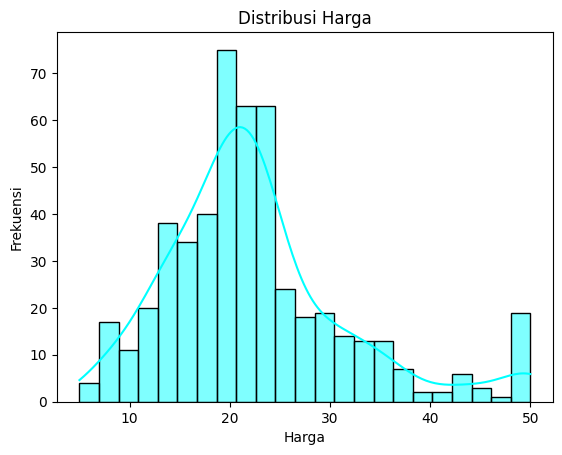

In [10]:
sns.histplot(df['MEDV'], kde=True, color='cyan')
plt.title('Distribusi Harga')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.show()

Interpetasi:

- Distribusi agak miring kanan dengan lonjakan di nilai 50 (harga di-cap). Mayoritas rumah berharga 17–25 ribu USD.

##  Preprocessing - Splitting Data

- Pisahkan target dengan fitur
- Bagi data 80/20.

In [11]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

x_train, x_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [12]:
print(f'x_train shape: {x_train.shape}')
print(f'x_test shape: {x_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

x_train shape: (404, 13)
x_test shape: (102, 13)
y_train shape: (404,)
y_test shape: (102,)


## Modeling - Gradient Boosting

In [13]:
grd_bst = GradientBoostingRegressor(n_estimators=100,
                                    learning_rate=0.1,
                                    max_features=3,
                                    random_state=42)
grd_bst.fit(x_train, y_train)
yp_gb = grd_bst.predict(x_test)

In [14]:
print(f'MSE: {mean_squared_error(y_test, yp_gb):.3f} Rb USD')
print(f'MAE: {mean_absolute_error(y_test, yp_gb):.3f} Rb USD')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, yp_gb)):.3f} Rb USD')
print(f'R²: {r2_score(y_test, yp_gb):.2}')


MSE: 10.446 Rb USD
MAE: 2.004 Rb USD
RMSE: 3.232 Rb USD
R²: 0.86


## Impact n_estimator dan learning_rate

### A) pengaruh terhadap R2 Score

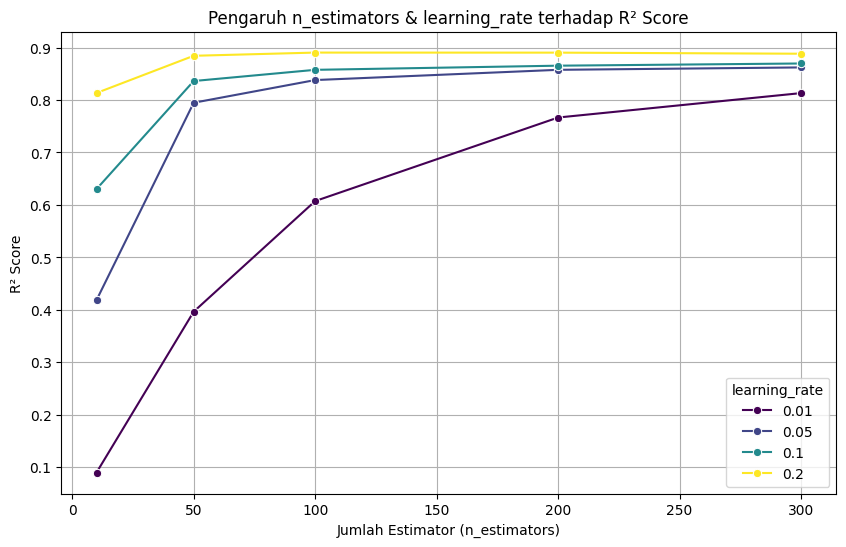

In [15]:
# Melakukan eksperimen dengan beberapa kombinasi n_estimators dan learning_rate
results = []
rates = [0.01, 0.05, 0.1, 0.2]
estimators = [10, 50, 100, 200, 300]

for lr in rates:
    for n_est in estimators:
        model = GradientBoostingRegressor(n_estimators=n_est, learning_rate=lr, max_features=3, random_state=42)
        model.fit(x_train, y_train)
        preds = model.predict(x_test)
        r2 = r2_score(y_test, preds)
        results.append({'learning_rate': lr, 'n_estimators': n_est, 'R2': r2})

# Membuat DataFrame dari hasil eksperimen
df_results = pd.DataFrame(results)

# Visualisasi
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_results, x='n_estimators', y='R2', hue='learning_rate', marker='o', palette='viridis')
plt.title('Pengaruh n_estimators & learning_rate terhadap R² Score')
plt.xlabel('Jumlah Estimator (n_estimators)')
plt.ylabel('R² Score')
plt.grid(True)
plt.show()

### B) Pengaruh terhadap RMSE

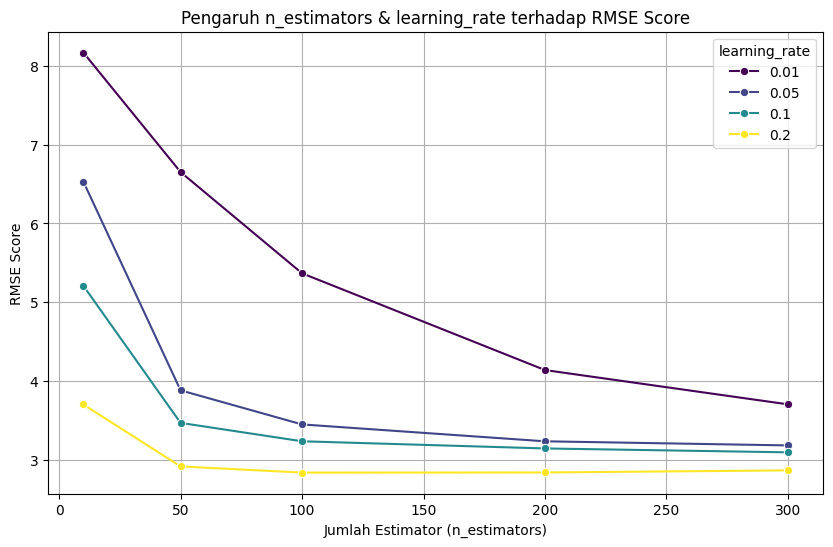

In [16]:
# Melakukan eksperimen dengan beberapa kombinasi n_estimators dan learning_rate
results = []
rates = [0.01, 0.05, 0.1, 0.2]
estimators = [10, 50, 100, 200, 300]

for lr in rates:
    for n_est in estimators:
        model = GradientBoostingRegressor(n_estimators=n_est,
                                          learning_rate=lr,
                                          max_features=3,
                                          random_state=42)
        model.fit(x_train, y_train)
        preds = model.predict(x_test)
        # Menghitung RMSE dengan benar menggunakan predictions saat ini
        RMSE_val = np.sqrt(mean_squared_error(y_test, preds))
        results.append({'learning_rate': lr, 'n_estimators': n_est, 'RMSE': RMSE_val})

# Membuat DataFrame dari hasil eksperimen
df_results = pd.DataFrame(results)

# Visualisasi
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_results,
             x='n_estimators',
             y='RMSE',
             hue='learning_rate',
             marker='o',
             palette='viridis')

plt.title('Pengaruh n_estimators & learning_rate terhadap RMSE Score')
plt.xlabel('Jumlah Estimator (n_estimators)')
plt.ylabel('RMSE Score')
plt.grid(True)
plt.show()

Interpretasi:

1. Pengaruh n_estimators (Jumlah Estimator / Pohon)
  - Pada $R^2$ Score (Grafik Kiri):
    - Secara umum, semakin banyak jumlah estimator (dari 10 ke 300), nilai $R^2$ cenderung meningkat (menuju angka 0.9).   
    - Peningkatan performa paling drastis terjadi pada rentang n_estimators 10 hingga 100. Setelah melewati angka 100-200, kurva mulai melandai (plateau), yang menandakan penambahan pohon lagi tidak memberikan peningkatan akurasi yang signifikan.
   - Pada RMSE Score (Grafik Kanan):
      - Sejalan dengan $R^2$, semakin banyak jumlah estimator, nilai error (RMSE) semakin menurun (menjadi semakin kecil/baik).   
     - Penurunan error paling tajam terjadi saat n_estimators dinaikkan dari 10 ke 100, lalu melandai di atas 200.
    
    
2. Pengaruh learning_rate (Kecepatan Belajar)
  - Peran Warna Garis:
      - Ungu (0.01): Learning rate paling lambat. Performa paling rendah ($R^2$ kecil, RMSE tinggi) karena model belajar terlalu lambat dan butuh jumlah pohon yang sangat banyak untuk bisa mengejar ketertinggalan.   
      - Biru & Toska (0.05 & 0.1): Memberikan hasil yang jauh lebih baik secara bertahap.
      - Kuning (0.2): Learning rate paling tinggi di grafik ini. Garis kuning langsung menduduki posisi teratas pada $R^2$ dan terbawah pada RMSE sejak jumlah pohon sedikit, menandakan model belajar dengan cepat dan efektif.   
      
      Artinya: Semakin tinggi nilai learning_rate, model mencapai performa optimal lebih cepat dengan jumlah pohon (n_estimators) yang lebih sedikit. Sebaliknya, learning_rate yang terlalu kecil (seperti 0.01) membutuhkan n_estimators yang jauh lebih besar agar modelnya matang.


💡Kesimpulan untuk Proses Belajarmu
  1.  Trade-off antara Kecepatan dan Performa: Kombinasi learning_rate yang agak tinggi (misalnya 0.1 atau 0.2) dengan n_estimators di kisaran 100–200 sudah menghasilkan performa yang sangat optimal dan stabil ($R^2$ tinggi, RMSE rendah).   
  2. Peringatan Overfitting: Meskipun learning_rate tinggi dan pohon yang banyak terlihat bagus di data uji ini, dalam kasus nyata kita harus tetap berhati-hati terhadap risiko overfitting jika model dilatih terlalu kompleks.

## Evaluasi dan Komparasi dengan Random Forest

### Comparasi model

In [17]:
# 1. Melatih Model Random Forest Regressor sebagai pembanding
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
yp_rf = rf_model.predict(x_test)

# 2. Membuat tabel komparasi performa
metrics_summary = {
    'Model': ['Gradient Boosting (Baseline)', 'Random Forest'],
    'MSE': [
        mean_squared_error(y_test, yp_gb),
        mean_squared_error(y_test, yp_rf)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, yp_gb)),
        np.sqrt(mean_squared_error(y_test, yp_rf))
    ],
    'MAE': [
        mean_absolute_error(y_test, yp_gb),
        mean_absolute_error(y_test, yp_rf)
    ],
    'R² Score': [
        r2_score(y_test, yp_gb),
        r2_score(y_test, yp_rf)
    ]
}

df_comparison = pd.DataFrame(metrics_summary)
df_comparison.round(4)

,Model,MSE,RMSE,MAE,R² Score
0,Gradient Boosting (Baseline),10.4462,3.2321,2.0040,0.8576
1,Random Forest,7.9015,2.8110,2.0395,0.8923


Interpretasi:

1. $R^2$ Score Lebih Tinggi: Random Forest memiliki nilai $R^2$ sebesar 0.8923, sedangkan Gradient Boosting (Baseline) ada di 0.8576. Ini berarti Random Forest mampu menjelaskan sekitar 89.23% variasi data, lebih unggul dibanding Gradient Boosting yang sekitar 85.76%.

2. Error Lebih Rendah: Hampir semua metrik error (MSE, RMSE, MAE) pada Random Forest lebih kecil dibandingkan Gradient Boosting:
   - MSE: Random Forest (7.9015) jauh lebih kecil daripada Gradient Boosting (10.4462).
   - RMSE: Random Forest (2.8110) lebih rendah dari Gradient Boosting (3.2321).
   - MAE: Random Forest (2.0395) sedikit lebih kecil daripada Gradient Boosting (2.0040 — catatan: pada MAE nilainya hampir setara, tetapi Random Forest unggul telak di metrik MSE dan RMSE yang memberikan penalti pada error besar).

   
Kesimpulan:
Meskipun Gradient Boosting adalah algoritma yang sangat kuat, dalam eksperimen dan baseline ini, Random Forest memberikan performa prediksi yang lebih akurat dan stabil.

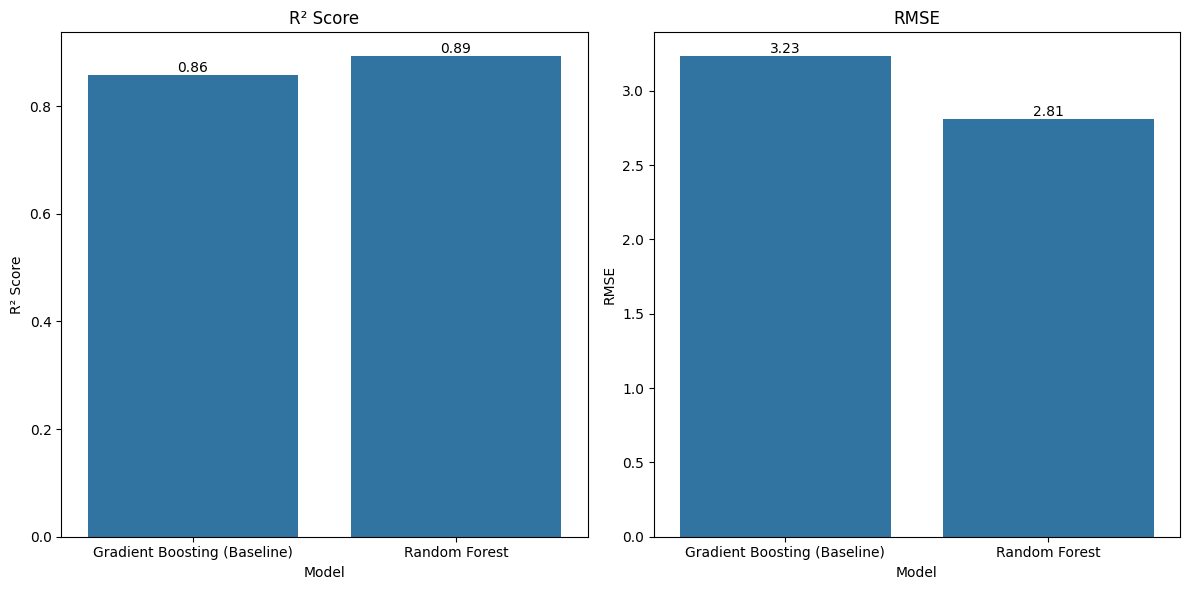

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot untuk Gradient Boosting
sns.barplot(x='Model', y='R² Score', data=df_comparison, ax=axes[0])
axes[0].set_title('R² Score')
for i in range(len(df_comparison)):
    axes[0].text(i, df_comparison['R² Score'][i], round(df_comparison['R² Score'][i], 2), ha='center', va='bottom')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('R² Score')

# Plot untuk Random Forest
sns.barplot(x='Model', y='RMSE', data=df_comparison, ax=axes[1])
axes[1].set_title('RMSE')
for i in range(len(df_comparison)):
    axes[1].text(i, df_comparison['RMSE'][i], round(df_comparison['RMSE'][i], 2), ha='center', va='bottom')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()

Interpretasi:
- Untuk percobaan saat ini Random Forest mengungguli Gradient Boosting
- Dengan nilai R2 Score lebih tinggi dan RMSE lebih rendah


### Feature Importance Gradient Boosting

In [24]:
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()

/tmp/ipykernel_6120/1248513079.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(feat_imp[i], i, round(feat_imp[i], 2), ha='left', va='center')


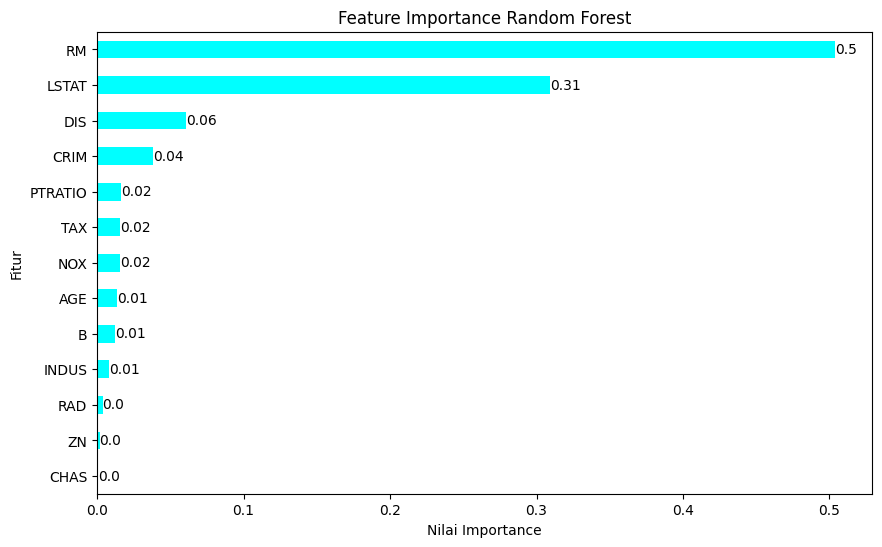

In [27]:
feat_imp.plot(kind='barh', color='cyan', figsize=(10, 6))
plt.title('Feature Importance Random Forest')
plt.xlabel('Nilai Importance')
plt.ylabel('Fitur')
for i in range(len(feat_imp)):
    plt.text(feat_imp[i], i, round(feat_imp[i], 2), ha='left', va='center')
plt.show()

Interpretasi:
-  `LSTAT` dan `RM` mendominasi importance — konsisten dengan
analisis korelasi.


**Insight:** status ekonomi lingkungan dan jumlah kamar adalah dua faktor terpenting penentu harga rumah Boston.

### Prediction vs Actual

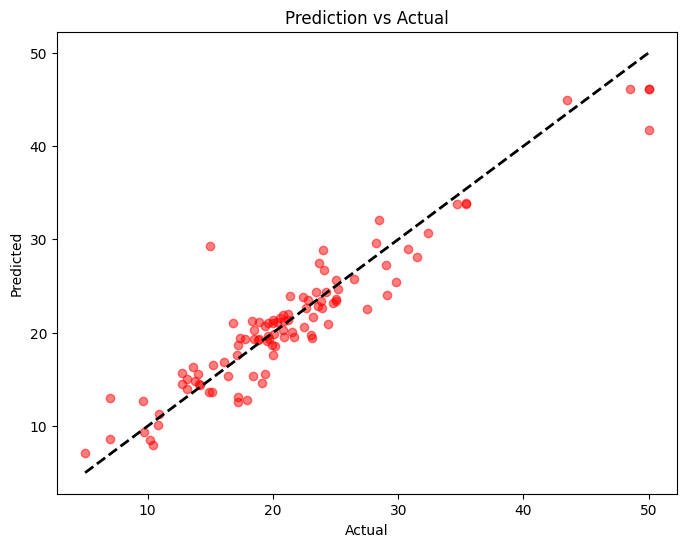

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, yp_rf, alpha=0.5, color='red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Prediction vs Actual')
plt.show()

Intrepretasi:

-  Titik rapat di sekitar garis Hitam → prediksi akurat.
Penyimpangan terbesar pada rumah termahal (harga di-*cap* 50).

### **📌 Kesimpulan Akhir & Insight Praktis**

Berdasarkan seluruh rangkaian analisis data dan eksperimen pemodelan menggunakan **Gradient Boosting** dan **Random Forest** pada dataset *Boston Housing*, berikut adalah rangkuman kesimpulan utama:

---

#### **1. Faktor Kunci Penentu Harga Rumah (Insight Bisnis)**
* **Faktor Terpenting:** Atribut fisik **`RM`** (rata-rata jumlah kamar) dan indikator sosial-ekonomi **`LSTAT`** (persentase penduduk kelas ekonomi bawah) secara konsisten mendominasi sebagai fitur yang paling berpengaruh.
* **Korelasi & Feature Importance:**
  * `RM` berkorelasi positif sangat kuat (+0.70) dengan kontribusi kepentingan (*importance*) mencapai **~50%**.
  * `LSTAT` berkorelasi negatif sangat kuat (-0.74) dengan kontribusi kepentingan mencapai **~31%**.
  * Fitur-fitur lain seperti jarak ke pusat ketenagakerjaan (`DIS`) dan tingkat kriminalitas (`CRIM`) memiliki pengaruh namun dalam skala yang jauh lebih kecil.

---

#### **2. Perbandingan Performa Model (Machine Learning)**
* **Random Forest Mengungguli Gradient Boosting Baseline:**
  * **R² Score:** Random Forest mampu menjelaskan **89.2%** variansi harga rumah (`R² = 0.892`), lebih tinggi dibandingkan Gradient Boosting baseline yang berada di angka **85.8%** (`R² = 0.858`).
  * **Tingkat Error (RMSE):** Rata-rata selisih prediksi Random Forest lebih kecil, yaitu **2.81 Rb USD** dibanding Gradient Boosting sebesar **3.23 Rb USD**.
* **Keterbatasan Prediksi:** Kedua model menunjukkan deviasi terbesar pada kategori rumah mewah (dengan label harga aktual `50` / capped). Hal ini disebabkan oleh pembatasan nilai (*censored data*) pada dataset asli yang membatasi kemampuan model mempelajari pola harga di atas nilai tersebut.

---

#### **3. Dinamika Hyperparameter pada Gradient Boosting**
* **Pentingnya Menyetel `learning_rate` & `n_estimators`:**
  * Laju pembelajaran yang terlalu lambat (`learning_rate = 0.01`) membutuhkan jumlah pohon (`n_estimators`) yang sangat besar (>300) untuk bisa mencapai akurasi optimal.
  * Laju pembelajaran yang lebih agresif (`learning_rate = 0.1` atau `0.2`) mempercepat proses konvergensi model secara signifikan. Hanya dengan **50-100 pohon**, model sudah mencapai performa optimal (RMSE terendah ~2.83) sebelum grafiknya melandai (*plateau*).
  
---

#### **💡 Rekomendasi / Langkah Selanjutnya**
1. **Gunakan Tuning Parameter Lebih Lanjut:** Performa Gradient Boosting baseline (85.8%) dapat melampaui Random Forest jika dilakukan penyetelan parameter yang lebih presisi menggunakan *GridSearchCV* atau *RandomizedSearchCV*.
2. **Gunakan Model Ensemble Gabungan:** Karena kedua model memiliki karakteristik yang kuat namun berbeda cara kerjanya (bagging vs boosting), metode *voting* atau *stacking* (menggabungkan prediksi kedua model) berpotensi menghasilkan akurasi yang jauh lebih tinggi dan stabil.